<a href="https://colab.research.google.com/github/mysciz/xjtu-ml-class/blob/main/exp/code/ml-exp2-seq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 导入库并初始化设备

In [10]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path

#不在colab请注释下面两行
from google.colab import drive
drive.mount('/content/drive',force_remount=True)
filepaths=['./xjtu-ml-class/exp/data/UCR-ECG/UCR_ECG1_10000_11800_12100.txt',
           './xjtu-ml-class/exp/data/UCR-ECG/UCR_ECG2_15000_16000_16100.txt',
           './xjtu-ml-class/exp/data/UCR-ECG/UCR_ECG3_15000_16000_16100.txt',
           './xjtu-ml-class/exp/data/UCR-ECG/UCR_ECG4_5000_16900_17100.txt']
# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# 检查CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

Mounted at /content/drive
使用设备: cpu


### 时序数据集类

In [4]:
class TimeSeriesDataset(Dataset):
    """时间序列数据集类"""
    def __init__(self, data, input_len, output_len):
        if data.ndim == 1:
            data = data.reshape(-1, 1)

        self.data = torch.FloatTensor(data)
        self.input_len = input_len
        self.output_len = output_len
        self.n_features = data.shape[1]

        # 创建样本
        self.X = []
        self.y = []
        for i in range(len(data) - input_len - output_len + 1):
            self.X.append(data[i:i+input_len])
            self.y.append(data[i+input_len:i+input_len+output_len])

        self.X = torch.FloatTensor(np.array(self.X))
        self.y = torch.FloatTensor(np.array(self.y))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

### 数据预处理类

In [5]:
class ECGDataLoader:
    """ECG数据加载器 - 一键加载和预处理（支持单文件或多文件）"""

    def __init__(self, filepaths, input_len=50, output_len=10,
                 train_ratio=0.7, val_ratio=0.15, batch_size=64):
        """
        一键加载ECG数据并创建数据加载器

        Args:
            filepaths: 文件路径，可以是字符串（单文件）或列表（多文件）
            input_len: 输入序列长度
            output_len: 输出序列长度（预测步数）
            train_ratio: 训练集比例
            val_ratio: 验证集比例
            batch_size: 批次大小
        """
        self.input_len = input_len
        self.output_len = output_len
        self.batch_size = batch_size
        self.scaler = StandardScaler()

        # 加载并预处理数据
        self._load_data(filepaths)
        self._prepare_datasets(train_ratio, val_ratio)
        self._create_dataloaders()

    def _load_data(self, filepaths):
        """加载单文件或多文件数据"""
        # 统一转换为列表
        if isinstance(filepaths, str):
            filepaths = [filepaths]

        all_data = []
        for filepath in filepaths:
            data = []
            with open(filepath, 'r') as f:
                for line in f:
                    line = line.strip()
                    if line:
                        try:
                            data.append(float(line))
                        except:
                            continue

            if data:
                data_array = np.array(data)
                all_data.extend(data_array)
                print(f"加载 {Path(filepath).name}: {len(data_array)} 个数据点")
            else:
                print(f"警告: {filepath} 无有效数据")

        if not all_data:
            raise ValueError("没有加载到任何数据")

        self.raw_data = np.array(all_data)
        print(f"\n总数据点: {len(self.raw_data)}")
        print(f"数据范围: [{self.raw_data.min():.2f}, {self.raw_data.max():.2f}]")

    def _prepare_datasets(self, train_ratio, val_ratio):
        """准备数据集"""
        # 标准化
        data_scaled = self.scaler.fit_transform(self.raw_data.reshape(-1, 1)).flatten()

        # 划分
        n = len(data_scaled)
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))

        train_data = data_scaled[:train_end]
        val_data = data_scaled[train_end:val_end]
        test_data = data_scaled[val_end:]

        # 创建数据集
        self.train_dataset = TimeSeriesDataset(train_data, self.input_len, self.output_len)
        self.val_dataset = TimeSeriesDataset(val_data, self.input_len, self.output_len)
        self.test_dataset = TimeSeriesDataset(test_data, self.input_len, self.output_len)

        print(f"\n数据集划分:")
        print(f"  训练样本: {len(self.train_dataset)}")
        print(f"  验证样本: {len(self.val_dataset)}")
        print(f"  测试样本: {len(self.test_dataset)}")

    def _create_dataloaders(self):
        """创建数据加载器"""
        self.train_loader = DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)
        self.val_loader = DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)
        self.test_loader = DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

    def inverse_transform(self, data):
        """反标准化"""
        return self.scaler.inverse_transform(data.reshape(-1, 1)).flatten()

### 实现LSTM

In [6]:
class LSTMCell(nn.Module):
    """单个LSTM单元"""
    def __init__(self, input_size, hidden_size):
        super(LSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        # 输入门、遗忘门、输出门、细胞状态更新的权重和偏置
        self.W_ih = nn.Linear(input_size, 4 * hidden_size, bias=True)
        self.W_hh = nn.Linear(hidden_size, 4 * hidden_size, bias=True)

    def forward(self, x, state):
        h, c = state

        # 线性变换
        gates = self.W_ih(x) + self.W_hh(h)

        # 分割成4个门
        i_gate, f_gate, g_gate, o_gate = gates.chunk(4, dim=1)

        # 激活函数
        i = torch.sigmoid(i_gate)  # 输入门
        f = torch.sigmoid(f_gate)  # 遗忘门
        g = torch.tanh(g_gate)     # 候选细胞状态
        o = torch.sigmoid(o_gate)  # 输出门

        # 更新细胞状态和隐藏状态
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)

        return h_next, c_next

class LSTMTimeSeries(nn.Module):
    """从零实现的多层LSTM模型"""
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(LSTMTimeSeries, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout_rate = dropout

        # 创建多层LSTM单元
        self.cells = nn.ModuleList()
        for i in range(num_layers):
            in_size = input_size if i == 0 else hidden_size
            self.cells.append(LSTMCell(in_size, hidden_size))

        # Dropout层
        self.dropout = nn.Dropout(dropout)

        # 输出层
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        device = x.device

        # 初始化隐藏状态和细胞状态
        h = [torch.zeros(batch_size, self.hidden_size).to(device) for _ in range(self.num_layers)]
        c = [torch.zeros(batch_size, self.hidden_size).to(device) for _ in range(self.num_layers)]

        # 遍历时间步
        for t in range(seq_len):
            x_t = x[:, t, :]

            # 逐层更新
            for layer in range(self.num_layers):
                if layer == 0:
                    input_t = x_t
                else:
                    input_t = h[layer-1]
                    if t < seq_len - 1:
                        input_t = self.dropout(input_t)

                h[layer], c[layer] = self.cells[layer](input_t, (h[layer], c[layer]))

            if t == seq_len - 1:
                last_output = h[-1]

        last_output = self.dropout(last_output)
        output = self.fc(last_output)

        return output

### 实现GRU

In [7]:
class GRUCell(nn.Module):
    """单个GRU单元"""
    def __init__(self, input_size, hidden_size):
        super(GRUCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        # 更新门、重置门、候选隐藏状态的权重
        self.W_ih = nn.Linear(input_size, 3 * hidden_size, bias=True)
        self.W_hh = nn.Linear(hidden_size, 3 * hidden_size, bias=True)

    def forward(self, x, h):
        # 线性变换
        gates_x = self.W_ih(x)
        gates_h = self.W_hh(h)

        # 分割成3个门
        z_gate, r_gate, n_gate = gates_x.chunk(3, dim=1)
        z_h, r_h, n_h = gates_h.chunk(3, dim=1)

        # 更新门和重置门
        z = torch.sigmoid(z_gate + z_h)
        r = torch.sigmoid(r_gate + r_h)

        # 候选隐藏状态
        n = torch.tanh(n_gate + r * n_h)

        # 更新隐藏状态
        h_next = (1 - z) * n + z * h

        return h_next

class GRUTimeSeries(nn.Module):
    """从零实现的多层GRU模型"""
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(GRUTimeSeries, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout_rate = dropout

        # 创建多层GRU单元
        self.cells = nn.ModuleList()
        for i in range(num_layers):
            in_size = input_size if i == 0 else hidden_size
            self.cells.append(GRUCell(in_size, hidden_size))

        # Dropout层
        self.dropout = nn.Dropout(dropout)

        # 输出层
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        device = x.device

        # 初始化隐藏状态
        h = [torch.zeros(batch_size, self.hidden_size).to(device) for _ in range(self.num_layers)]

        # 遍历时间步
        for t in range(seq_len):
            x_t = x[:, t, :]

            # 逐层更新
            for layer in range(self.num_layers):
                if layer == 0:
                    input_t = x_t
                else:
                    input_t = h[layer-1]
                    if t < seq_len - 1:
                        input_t = self.dropout(input_t)

                h[layer] = self.cells[layer](input_t, h[layer])

            if t == seq_len - 1:
                last_output = h[-1]

        last_output = self.dropout(last_output)
        output = self.fc(last_output)

        return output

### Train模块

In [13]:
class TimeSeriesTrainer:
    """时间序列预测训练器类"""

    def __init__(self, model, device=None):
        """
        初始化训练器
        Args:
            model: 要训练的模型
            device: 计算设备，如果为None则自动选择
        """
        self.model = model
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")
        self.model = self.model.to(self.device)

        # 初始化记录
        self.reset()

    def reset(self):
        """重置训练历史记录（不重置模型参数）"""
        self.train_losses = []
        self.val_losses = []
        self.test_maes = []
        self.test_rmses = []
        self.step_maes_history = []

        self.best_val_loss = float('inf')
        self.best_epoch = -1
        self.best_model_state = None

        print("训练历史已重置")
        return self

    def reset_model(self):
        """重置模型参数（重新初始化）"""
        def init_weights(m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name:
                        nn.init.xavier_uniform_(param)
                    elif 'weight_hh' in name:
                        nn.init.orthogonal_(param)
                    elif 'bias' in name:
                        nn.init.zeros_(param)
            elif isinstance(m, nn.GRU):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name:
                        nn.init.xavier_uniform_(param)
                    elif 'weight_hh' in name:
                        nn.init.orthogonal_(param)
                    elif 'bias' in name:
                        nn.init.zeros_(param)

        self.model.apply(init_weights)
        self.reset()
        print("模型参数已重新初始化")
        return self

    def train(self, train_loader, val_loader, epochs=100,
              optimizer_name='adam', lr=0.001, weight_decay=0,
              scheduler_type='cosine', early_stopping_patience=None,
              verbose=True, reset_history=True):
        """
        训练模型
        """
        if reset_history:
            self.reset()

        criterion = nn.MSELoss()
        optimizer = self._get_optimizer(optimizer_name, lr, weight_decay)
        scheduler = self._get_scheduler(optimizer, scheduler_type, epochs)

        patience_counter = 0

        for epoch in range(epochs):
            # 训练一个epoch
            train_loss = self._train_epoch(train_loader, criterion, optimizer, epoch, epochs, verbose)

            # 验证
            val_metrics = self.evaluate(val_loader, verbose=False)

            # 记录历史
            self.train_losses.append(train_loss)
            self.val_losses.append(val_metrics['MAE'])
            self.test_maes.append(val_metrics['MAE'])
            self.test_rmses.append(val_metrics['RMSE'])
            self.step_maes_history.append(val_metrics['step_MAE'])

            # 保存最佳模型
            if val_metrics['MAE'] < self.best_val_loss:
                self.best_val_loss = val_metrics['MAE']
                self.best_epoch = epoch + 1
                self._save_best_model()
                patience_counter = 0
            else:
                patience_counter += 1

            # 早停检查
            if early_stopping_patience and patience_counter >= early_stopping_patience:
                if verbose:
                    print(f"\n早停触发于 epoch {epoch+1}")
                break

            # 更新学习率
            if scheduler:
                if scheduler_type.lower() == 'plateau':
                    scheduler.step(val_metrics['MAE'])
                else:
                    scheduler.step()

            # 打印进度
            if verbose and (epoch + 1) % 10 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(f'Epoch {epoch+1}/{epochs}: '
                      f'Train Loss: {train_loss:.6f}, '
                      f'Val MAE: {val_metrics["MAE"]:.4f}, '
                      f'Val RMSE: {val_metrics["RMSE"]:.4f}, '
                      f'LR: {current_lr:.6f}')

        # 训练结束，恢复最佳模型
        self._restore_best_model()

        if verbose:
            print(f"\n训练完成！最佳验证MAE: {self.best_val_loss:.4f} (Epoch {self.best_epoch})")

        return self

    def _train_epoch(self, train_loader, criterion, optimizer, epoch, total_epochs, verbose):
        """训练一个epoch"""
        self.model.train()
        running_loss = 0.0

        iterator = tqdm(train_loader, desc=f'Epoch {epoch+1}/{total_epochs}') if verbose else train_loader

        for X_batch, y_batch in iterator:
            X_batch = X_batch.to(self.device)
            y_batch = y_batch.to(self.device)
            if y_batch.dim() == 3 and y_batch.shape[-1] == 1:
              y_batch = y_batch.squeeze(-1)

            optimizer.zero_grad()
            y_pred = self.model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

            if verbose:
                iterator.set_postfix({'loss': loss.item()})

        train_loss = running_loss / len(train_loader.dataset)
        return train_loss

    def evaluate(self, dataloader, scaler=None, verbose=False):
        """评估模型"""
        self.model.eval()

        predictions = []
        targets = []

        with torch.no_grad():
            for X_batch, y_batch in dataloader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)
                if y_batch.dim() == 3 and y_batch.shape[-1] == 1:
                  y_batch = y_batch.squeeze(-1)
                y_pred = self.model(X_batch)

                predictions.append(y_pred.cpu().numpy())
                targets.append(y_batch.cpu().numpy())

        predictions = np.concatenate(predictions, axis=0)
        targets = np.concatenate(targets, axis=0)

        # 反标准化
        if scaler:
            n_samples, n_steps = predictions.shape
            predictions = scaler.inverse_transform(predictions.reshape(-1, 1)).reshape(n_samples, n_steps)
            targets = scaler.inverse_transform(targets.reshape(-1, 1)).reshape(n_samples, n_steps)

        # 计算指标
        mae = mean_absolute_error(targets.flatten(), predictions.flatten())
        rmse = np.sqrt(mean_squared_error(targets.flatten(), predictions.flatten()))

        step_mae = []
        step_rmse = []
        for step in range(targets.shape[1]):
            step_mae.append(mean_absolute_error(targets[:, step], predictions[:, step]))
            step_rmse.append(np.sqrt(mean_squared_error(targets[:, step], predictions[:, step])))

        metrics = {
            'MAE': mae,
            'RMSE': rmse,
            'step_MAE': step_mae,
            'step_RMSE': step_rmse,
            'predictions': predictions,
            'targets': targets
        }

        if verbose:
            self._print_metrics(metrics)

        return metrics

    def _print_metrics(self, metrics):
        """打印评估指标"""
        print("\n" + "="*60)
        print("模型评估结果")
        print("="*60)
        print(f"整体MAE: {metrics['MAE']:.4f}")
        print(f"整体RMSE: {metrics['RMSE']:.4f}")
        print(f"\n各步长预测结果:")
        print(f"{'步长':<8} {'MAE':<12} {'RMSE':<12}")
        print("-"*32)
        for i in range(len(metrics['step_MAE'])):
            print(f"Step {i+1:<3} {metrics['step_MAE'][i]:<12.4f} {metrics['step_RMSE'][i]:<12.4f}")

    def predict(self, X, scaler=None):
        """对单个输入进行预测"""
        self.model.eval()

        if not isinstance(X, torch.Tensor):
            X = torch.FloatTensor(X)

        if X.dim() == 2:
            X = X.unsqueeze(0)

        X = X.to(self.device)

        with torch.no_grad():
            predictions = self.model(X)
            predictions = predictions.cpu().numpy()

        if scaler:
            n_samples, n_steps = predictions.shape
            predictions = scaler.inverse_transform(predictions.reshape(-1, 1)).reshape(n_samples, n_steps)

        return predictions.squeeze()

    def plot_history(self):
        """绘制训练历史曲线"""
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # 损失曲线
        axes[0].plot(self.train_losses, label='Train Loss', color='blue')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Loss')
        axes[0].legend()
        axes[0].grid(True)

        # 验证MAE曲线
        axes[1].plot(self.val_losses, label='Val MAE', color='red')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('MAE')
        axes[1].set_title('Validation MAE')
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    def plot_predictions(self, dataloader, scaler=None, num_samples=3):
        """绘制预测结果对比图"""
        metrics = self.evaluate(dataloader, scaler=scaler, verbose=False)
        predictions = metrics['predictions']
        targets = metrics['targets']

        fig, axes = plt.subplots(num_samples, 1, figsize=(10, 3*num_samples))
        if num_samples == 1:
            axes = [axes]

        for i in range(min(num_samples, len(predictions))):
            steps = range(1, len(predictions[i]) + 1)
            axes[i].plot(steps, targets[i], 'o-', label='Actual', markersize=6, linewidth=2)
            axes[i].plot(steps, predictions[i], 's--', label='Predicted', markersize=6, linewidth=2)
            axes[i].set_xlabel('Prediction Step')
            axes[i].set_ylabel('Value')
            axes[i].set_title(f'Sample {i+1}')
            axes[i].legend()
            axes[i].grid(True)

        plt.tight_layout()
        plt.show()

    def _get_optimizer(self, optimizer_name, lr, weight_decay):
        """获取优化器"""
        if optimizer_name.lower() == 'adam':
            return optim.Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        elif optimizer_name.lower() == 'sgd':
            return optim.SGD(self.model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
        elif optimizer_name.lower() == 'rmsprop':
            return optim.RMSprop(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        else:
            raise ValueError(f"不支持的优化器: {optimizer_name}")

    def _get_scheduler(self, optimizer, scheduler_type, epochs):
        """获取学习率调度器"""
        if scheduler_type.lower() == 'cosine':
            return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        elif scheduler_type.lower() == 'step':
            return optim.lr_scheduler.StepLR(optimizer, step_size=epochs//3, gamma=0.1)
        elif scheduler_type.lower() == 'plateau':
            return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
        else:
            return None

    def _save_best_model(self):
        """保存最佳模型"""
        self.best_model_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}

    def _restore_best_model(self):
        """恢复最佳模型"""
        if hasattr(self, 'best_model_state') and self.best_model_state:
            self.model.load_state_dict(self.best_model_state)
            self.model.to(self.device)

    def save_model(self, path):
        """保存模型到文件"""
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'best_val_loss': self.best_val_loss,
            'best_epoch': self.best_epoch
        }, path)
        print(f"模型已保存到: {path}")

    def load_model(self, path):
        """从文件加载模型"""
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.train_losses = checkpoint.get('train_losses', [])
        self.val_losses = checkpoint.get('val_losses', [])
        self.best_val_loss = checkpoint.get('best_val_loss', float('inf'))
        self.best_epoch = checkpoint.get('best_epoch', -1)
        print(f"模型已从: {path} 加载")

    def get_model(self):
        """返回模型"""
        return self.model

### 测试
#### LSTM

加载 UCR_ECG1_10000_11800_12100.txt: 30000 个数据点
加载 UCR_ECG2_15000_16000_16100.txt: 30000 个数据点
加载 UCR_ECG3_15000_16000_16100.txt: 30000 个数据点
加载 UCR_ECG4_5000_16900_17100.txt: 30000 个数据点

总数据点: 120000
数据范围: [-167.00, 186.00]

数据集划分:
  训练样本: 83941
  验证样本: 17941
  测试样本: 17941
Using device: cpu
训练历史已重置
训练历史已重置


Epoch 10/50: 100%|██████████| 1312/1312 [02:11<00:00, 10.00it/s, loss=0.0278]


Epoch 10/50: Train Loss: 0.031832, Val MAE: 0.1163, Val RMSE: 0.1864, LR: 0.000905


Epoch 20/50: 100%|██████████| 1312/1312 [02:10<00:00, 10.06it/s, loss=0.0163]


Epoch 20/50: Train Loss: 0.025990, Val MAE: 0.1167, Val RMSE: 0.1916, LR: 0.000655


...

Epoch 30/50: Train Loss: 0.022375, Val MAE: 0.1102, Val RMSE: 0.1715, LR: 0.000345


Epoch 40/50: 100%|██████████| 1312/1312 [02:09<00:00, 10.14it/s, loss=0.0388]


Epoch 40/50: Train Loss: 0.020262, Val MAE: 0.1031, Val RMSE: 0.1647, LR: 0.000095


Epoch 50/50: 100%|██████████| 1312/1312 [02:11<00:00, 10.01it/s, loss=0.0319]


Epoch 50/50: Train Loss: 0.019650, Val MAE: 0.1027, Val RMSE: 0.1661, LR: 0.000000

训练完成！最佳验证MAE: 0.1027 (Epoch 49)


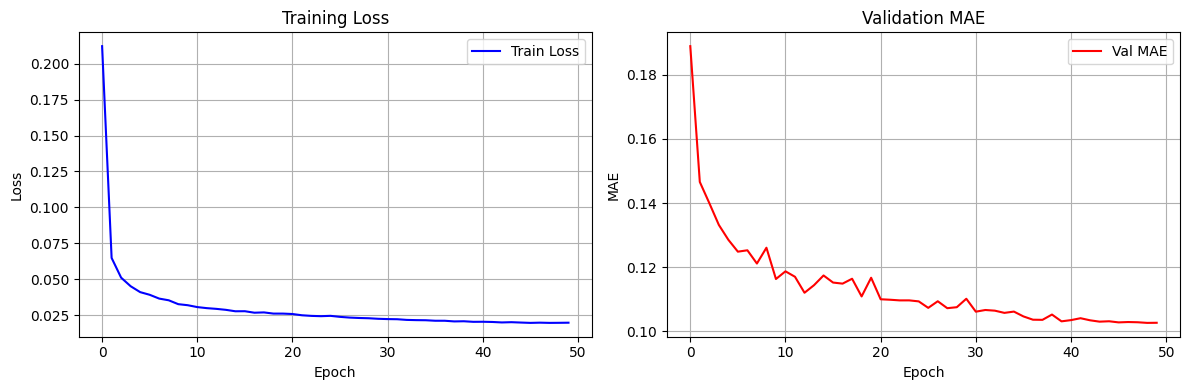


模型评估结果
整体MAE: 2.6225
整体RMSE: 5.0789

各步长预测结果:
步长       MAE          RMSE        
--------------------------------
Step 1   1.9191       3.3556      
Step 2   2.4295       4.1838      
Step 3   2.5409       4.5332      
Step 4   2.5791       4.7557      
Step 5   2.6354       4.9876      
Step 6   2.6822       5.2374      
Step 7   2.7363       5.4658      
Step 8   2.8065       5.6444      
Step 9   2.9002       5.8646      
Step 10  2.9962       6.1313      


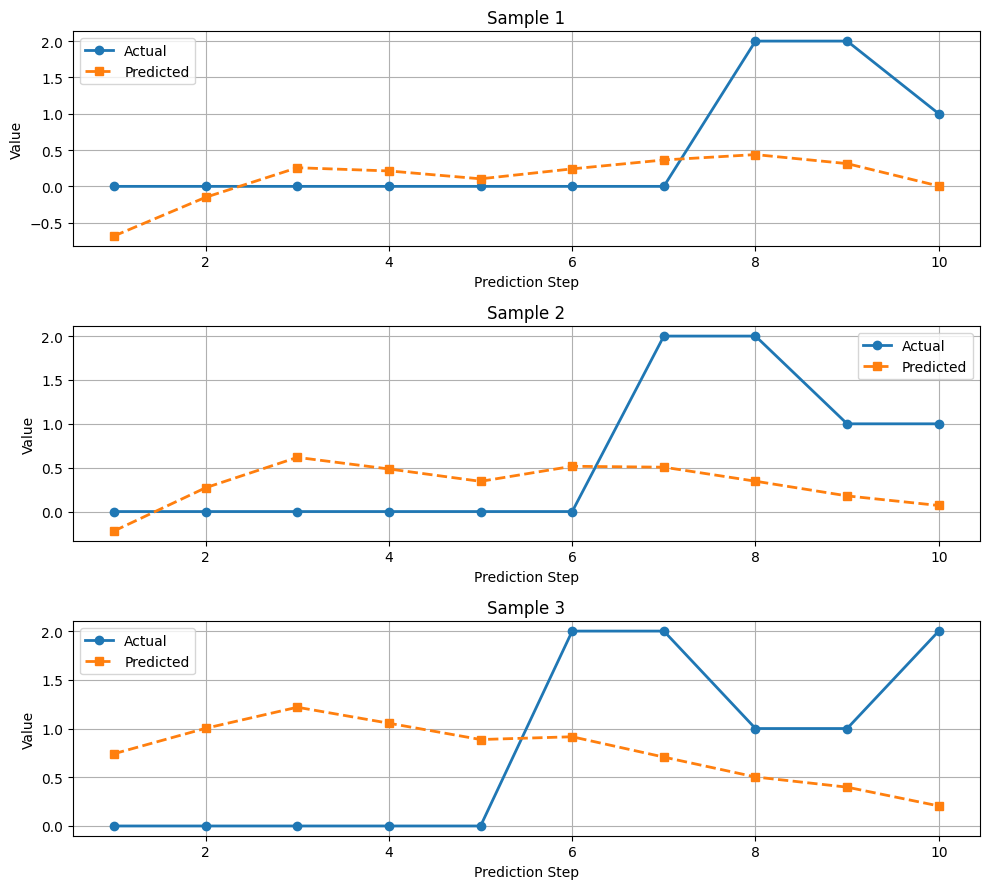

RuntimeError: Parent directory ./content/drive does not exist.

In [15]:
# 1. 加载数据
data_loader = ECGDataLoader(
    filepaths=filepaths,
    input_len=50,
    output_len=10,
    batch_size=64
)
# 2. 创建模型
model = LSTMTimeSeries(
    input_size=1,        # 单变量时间序列
    hidden_size=64,
    num_layers=2,
    output_size=10,      # 预测10个点
    dropout=0.2
)
# 3. 创建训练器
trainer = TimeSeriesTrainer(model, device)
# 4. 训练模型
trainer.train(
    train_loader=data_loader.train_loader,
    val_loader=data_loader.val_loader,
    epochs=50,
    optimizer_name='adam',
    lr=0.001,
    weight_decay=1e-5,
    scheduler_type='cosine',
    early_stopping_patience=20,
    verbose=True
)
# 5. 绘制训练曲线
trainer.plot_history()
# 6. 最终评估
metrics = trainer.evaluate(
    dataloader=data_loader.test_loader,
    scaler=data_loader.scaler,
    verbose=True
)
# 7. 可视化预测结果
trainer.plot_predictions(
    dataloader=data_loader.test_loader,
    scaler=data_loader.scaler,
    num_samples=3
)
# 8. 保存模型
trainer.save_model('/content/drive/lstm_lr1_adam_batch64.pth')